In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import plotly.express as px
import plotly.graph_objects as go
import us

In [2]:
df = pd.read_excel("GuttmacherInstituteAbortionDataByState.xlsx")

print(df.shape)
df.head()

(51, 31)


,U.S. State,"% change in abortion rate, 2017-2020","% change in the no. of abortion clinics, 2017-2020","% change in the no. of abortion providers, 2014-2017","% of all U.S. abortions, by state of occurrence, 2020","% of counties without a known abortion provider, 2014","% of counties without a known clinic, 2020","% of residents obtaining abortions who traveled out of state for care, 2020","% of women aged 15-44 living in a county without a clinic, 2020","% of women aged 15-44 living in a county without an abortion provider, 2014",...,"No. of abortions per 1,000 women aged 15–44, by state of occurrence, 2020","No. of abortions per 1,000 women aged 15–44, by state of residence, 2020","No. of abortions, by state of occurrence, 2020","No. of abortions, by state of residence, 2020","No. of federally funded abortions, 2010","No. of state funded abortions, 2010","Reported public expenditures for abortions (in 000s of dollars), federal, 2015","Reported public expenditures for abortions (in 000s of dollars), state, 2015","Total no. of publicly funded abortions , 2010","Total reported public expenditures for abortions (in 000s of dollars), 2015"
0,Alabama,-6,0,-22,0.6,91,93,47,59,58,...,6.0,9.5,5700,9060,9,0,22,0,9,22
1,Alaska,0,0,-25,0.1,79,87,7,33,17,...,8.6,9.2,1240,1320,0,835,0,216,835,216
2,Arizona,1,0,-8,1.4,80,80,6,18,19,...,9.3,9.7,13320,13820,1,13,28,11,14,40
3,Arkansas,2,-33,0,0.3,97,99,37,86,77,...,5.6,7.8,3250,4510,0,0,0,0,0,0
4,California,17,7,-18,16.6,24,38,0,3,1,...,19.2,19.0,154060,152400,0,88466,0,32613,88466,32613


In [3]:
desc = df.describe().T
desc[['mean','std','min','25%','50%','75%','max']]

,mean,std,min,25%,50%,75%,max
"% change in abortion rate, 2017-2020",2.117647,27.761590,-98.0,-6.00,1.0,9.50,100.0
"% change in the no. of abortion clinics, 2017-2020",0.764706,24.076203,-67.0,-8.00,0.0,9.00,100.0
"% change in the no. of abortion providers, 2014-2017",2.215686,33.367837,-40.0,-16.50,0.0,5.00,133.0
"% of all U.S. abortions, by state of occurrence, 2020",1.952941,3.128856,0.0,0.30,0.8,1.95,16.6
"% of counties without a known abortion provider, 2014",76.705882,27.835441,0.0,75.00,91.0,95.00,99.0
"% of counties without a known clinic, 2020",77.941176,27.170139,0.0,69.50,91.0,96.00,99.0
"% of residents obtaining abortions who traveled out of state for care, 2020",19.666667,23.557306,0.0,5.00,8.0,25.50,99.0
"% of women aged 15-44 living in a county without a clinic, 2020",45.725490,27.583385,0.0,22.50,47.0,66.50,96.0
"% of women aged 15-44 living in a county without an abortion provider, 2014",42.313725,26.798127,0.0,17.50,42.0,62.50,96.0
"Abortion rate (the no. of abortions per 1,000 women aged 15-19), by state of residence, 2017",6.631373,3.336674,3.1,4.50,5.9,7.55,19.8


In [4]:
missing = df.isna().sum().sort_values(ascending = False)
print(missing[missing > 0])

No. of abortions among women younger than 15, by state of residence, 2017    14
dtype: int64


In [5]:
df[df['No. of abortions among women younger than 15, by state of residence, 2017'].isna()]

,U.S. State,"% change in abortion rate, 2017-2020","% change in the no. of abortion clinics, 2017-2020","% change in the no. of abortion providers, 2014-2017","% of all U.S. abortions, by state of occurrence, 2020","% of counties without a known abortion provider, 2014","% of counties without a known clinic, 2020","% of residents obtaining abortions who traveled out of state for care, 2020","% of women aged 15-44 living in a county without a clinic, 2020","% of women aged 15-44 living in a county without an abortion provider, 2014",...,"No. of abortions per 1,000 women aged 15–44, by state of occurrence, 2020","No. of abortions per 1,000 women aged 15–44, by state of residence, 2020","No. of abortions, by state of occurrence, 2020","No. of abortions, by state of residence, 2020","No. of federally funded abortions, 2010","No. of state funded abortions, 2010","Reported public expenditures for abortions (in 000s of dollars), federal, 2015","Reported public expenditures for abortions (in 000s of dollars), state, 2015","Total no. of publicly funded abortions , 2010","Total reported public expenditures for abortions (in 000s of dollars), 2015"
1,Alaska,0,0,-25,0.1,79,87,7,33,17,...,8.6,9.2,1240,1320,0,835,0,216,835,216
7,Delaware,-5,-25,0,0.2,33,33,44,19,18,...,10.0,15.8,1830,2870,1,unavailable,"<1,000",0,1,"<1,000"
8,District of Columbia,62,0,-11,1.0,0,0,45,0,0,...,48.9,26.1,9410,5010,0,0,0,0,0,nr
15,Iowa,-6,-25,-31,0.4,89,95,12,65,42,...,5.9,5.9,3510,3510,3,20,0,nr,23,nr
16,Kansas,19,0,0,0.9,97,98,4,60,56,...,14.5,7.3,8180,4120,0,0,0,nr,0,nr
19,Maine,15,6,133,0.3,75,12,5,16,46,...,10.1,10.1,2370,2370,15,unavailable,0,0,15,0
26,Montana,-1,20,0,0.2,93,91,3,47,55,...,8.2,7.6,1630,1510,5,417,unavailable,238,422,238
27,Nebraska,7,0,40,0.2,97,97,8,39,41,...,5.9,5.4,2200,2020,0,unavailable,0,nr,unavailable,nr
29,New Hampshire,-10,0,0,0.2,40,60,23,30,12,...,8.3,8.7,2050,2150,3,0,0,nr,3,nr
34,North Dakota,-1,0,0,0.1,98,98,13,72,73,...,7.8,6.4,1170,960,0,0,0,nr,0,nr


In [6]:
col = 'No. of abortions among women younger than 15, by state of residence, 2017'
median_val = df[col].median()
df[col] = df[col].fillna(median_val)

In [7]:
df.describe()
missing = df.isna().sum().sort_values(ascending = False)
print(missing[missing > 0])

Series([], dtype: int64)


In [8]:
df.columns = df.columns.str.replace('–', '-', regex=False)

df = df.rename(columns={
    'No. of abortions per 1,000 women aged 15-44, by state of occurrence, 2020':
    'abort_rate_15_44_2020'
})

name_to_abbr = {s.name: s.abbr for s in us.states.STATES}
df['state_abbrev'] = df['U.S. State'].map(name_to_abbr)
col = 'abort_rate_15_44_2020'

fig = px.choropleth(
    df,
    locations='state_abbrev',
    locationmode='USA-states',
    color=col,
    scope='usa',
    title='2020 Abortion Rate per 1,000 Women by State'
)

fig.show()

Pearson correlation: r = 0.60, p = 0.000


Text(0.05, 0.95, 'r = 0.60')

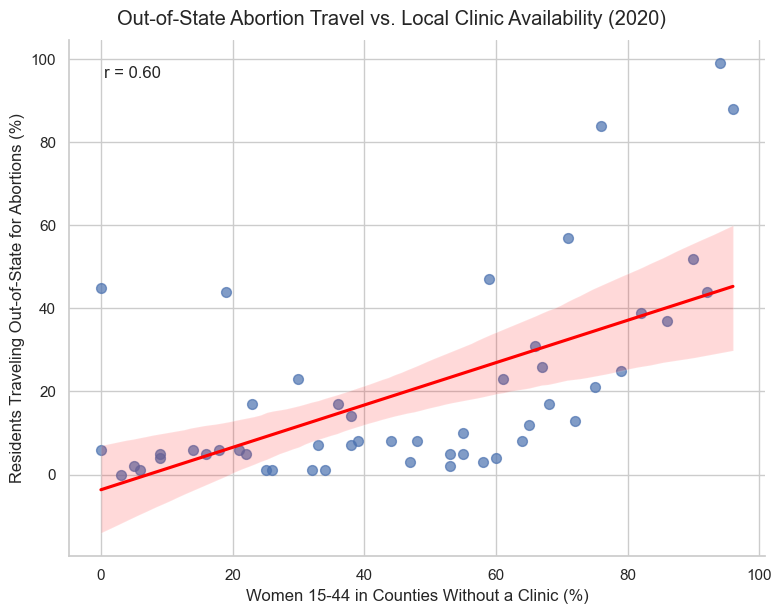

In [9]:
x_col = '% of women aged 15-44 living in a county without a clinic, 2020'
y_col = '% of residents obtaining abortions who traveled out of state for care, 2020'

subset = df[[x_col, y_col]].dropna()

r, p_value = pearsonr(subset[x_col], subset[y_col])
print(f"Pearson correlation: r = {r:.2f}, p = {p_value:.3f}")

sns.set(style="whitegrid")
g = sns.lmplot(
    x=x_col,
    y=y_col,
    data=subset,
    height=6,
    aspect=1.33,
    scatter_kws={'s': 50, 'alpha': 0.7},
    line_kws={'color': 'red'}
)

g.fig.suptitle(
    'Out-of-State Abortion Travel vs. Local Clinic Availability (2020)',
    y=1.02
)
g.set_axis_labels(
    'Women 15-44 in Counties Without a Clinic (%)',
    'Residents Traveling Out-of-State for Abortions (%)'
)

ax = g.ax
ax.text(
    0.05, 0.95,
    f"r = {r:.2f}",
    transform=ax.transAxes,
    fontsize=12,
    va='top'
)

In [10]:
df.columns = df.columns.str.replace("–", "-", regex=False)

# 3. Create state postal abbreviation column
name_to_abbr = {s.name: s.abbr for s in us.states.STATES}
df["state_abbrev"] = df["U.S. State"].map(name_to_abbr)

# 4. Map each state to its Census region
region_map = {
    # Northeast
    "CT":"Northeast","ME":"Northeast","MA":"Northeast","NH":"Northeast",
    "RI":"Northeast","VT":"Northeast","NJ":"Northeast","NY":"Northeast","PA":"Northeast",
    # Midwest
    "IN":"Midwest","IL":"Midwest","MI":"Midwest","OH":"Midwest","WI":"Midwest",
    "IA":"Midwest","KS":"Midwest","MN":"Midwest","MO":"Midwest","NE":"Midwest",
    "ND":"Midwest","SD":"Midwest",
    # South
    "DE":"South","FL":"South","GA":"South","MD":"South","NC":"South","SC":"South",
    "VA":"South","DC":"South","WV":"South","AL":"South","KY":"South","MS":"South",
    "TN":"South","AR":"South","LA":"South","OK":"South","TX":"South",
    # West
    "AZ":"West","CO":"West","ID":"West","MT":"West","NV":"West","NM":"West",
    "UT":"West","WY":"West","AK":"West","CA":"West","HI":"West","OR":"West","WA":"West"
}
df["region"] = df["state_abbrev"].map(region_map)

# 5. Bin “% women 15–44 in county without a clinic” into access tiers
x_col = "% of women aged 15-44 living in a county without a clinic, 2020"
bins = [0, 33, 66, 100]
labels = ["Low access (<33%)", "Medium access (33–66%)", "High access (>66%)"]
df["access_tier"] = pd.cut(df[x_col], bins=bins, labels=labels, include_lowest=True)

# 6. Create a composite “access barrier index”
#    (product of normalized percent of counties & percent of women without clinics)
df["barrier_index"] = (
    df["% of counties without a known clinic, 2020"] / 100
    * df[x_col] / 100
)

# 7. (Optional) Compute regional averages for travel and clinic‐coverage
y_col = "% of residents obtaining abortions who traveled out of state for care, 2020"
regional_means = (
    df
    .groupby("region")[[x_col, y_col, "barrier_index"]]
    .mean()
    .reset_index()
)

# 8. Inspect the results
print(df[[
    "state_abbrev", "region", x_col, "access_tier", "barrier_index"
]].head())

print("\nRegional means:\n", regional_means)

  state_abbrev region  \
0           AL  South   
1           AK   West   
2           AZ   West   
3           AR  South   
4           CA   West   

   % of women aged 15-44 living in a county without a clinic, 2020  \
0                                                 59                 
1                                                 33                 
2                                                 18                 
3                                                 86                 
4                                                  3                 

              access_tier  barrier_index  
0  Medium access (33–66%)         0.5487  
1       Low access (<33%)         0.2871  
2       Low access (<33%)         0.1440  
3      High access (>66%)         0.8514  
4       Low access (<33%)         0.0114  

Regional means:
       region  % of women aged 15-44 living in a county without a clinic, 2020  \
0    Midwest                                          59.916667        

In [11]:
fig1 = px.scatter(
    df, x=x_col, y=y_col,
    color='barrier_index', size='barrier_index', size_max=20,
    color_continuous_scale='Blues', trendline='lowess',
    title='Local Access Barriers vs. Out-of-State Abortion Travel, 2020',
    labels={
        x_col: 'Women 15-44 in Counties Without a Clinic (%)',
        y_col: 'Out-of-State Abortions (%)',
        'barrier_index': 'Composite Barrier Index'
    }
)

fig1.update_layout(
    xaxis=dict(range=[0,100]),
    yaxis=dict(range=[0,100])
)

bins = [0, 25, 50, 75, 100]
df['clinic_bin_interval'] = pd.cut(
    df[x_col],
    bins=bins,
    include_lowest=True
)

bin_means = (
    df
    .groupby('clinic_bin_interval')[y_col]
    .mean()
    .reset_index(name='mean_travel')
)

bin_means['mid'] = bin_means['clinic_bin_interval'].apply(
    lambda iv: (iv.left + iv.right) / 2
)

bin_means['label'] = bin_means['clinic_bin_interval'].astype(str)

fig1.add_trace(
    go.Scatter(
        x=bin_means['mid'],
        y=bin_means['mean_travel'],
        mode='lines+markers',
        name='Mean by 25% Bin',
        line=dict(color='firebrick', dash='dash'),
        marker=dict(size=10, color='firebrick')
    )
)

fig1.update_coloraxes(
    colorbar=dict(
        x=1.5,
        yanchor='top',
        y=1.0
    )
)

fig1.update_layout(
    legend=dict(
        x=1.15,
        y=1.0,
        xanchor='left',
        yanchor='top'
    ),
    margin=dict(r=200)
)

fig1.add_shape(
    type='line',
    x0=0, x1=100, y0=20, y1=20,
    line=dict(color='black', dash='dot'),
    xref='x', yref='y'
)
fig1.add_annotation(
    x=5, y=22,
    text="20% travel threshold",
    showarrow=False,
    font=dict(color='black', size=10),
    xanchor='left'
)

fig1.show()

/var/folders/sd/54269wrn4fz6bkfc0cnb4n4h0000gn/T/ipykernel_40013/3623734838.py:27: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



/var/folders/sd/54269wrn4fz6bkfc0cnb4n4h0000gn/T/ipykernel_40013/397269845.py:20: FutureWarning:

Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.



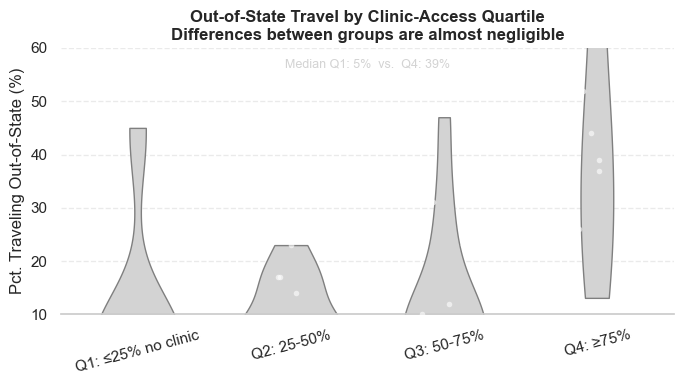

In [12]:
df['barrier_quartile'] = pd.qcut(
    df[x_col],
    q=4,
    labels=['Q1: ≤25% no clinic','Q2: 25-50%','Q3: 50-75%','Q4: ≥75%']
)

meds = (
    df
    .groupby('barrier_quartile', observed=True)[y_col]
    .median()
)
low_med = meds.loc['Q1: ≤25% no clinic']
high_med = meds.loc['Q4: ≥75%']

plt.figure(figsize=(7,4))
sns.violinplot(
    x='barrier_quartile', y=y_col, data=df,
    inner=None, cut=0, linewidth=1, color='lightgrey'
)
sns.stripplot(
    x='barrier_quartile', y=y_col, data=df,
    color='white', edgecolor='gray', alpha=0.6, jitter=0.15, size=4
)


plt.ylim(10, 60)

plt.title("Out-of-State Travel by Clinic-Access Quartile\n"
          "Differences between groups are almost negligible", 
          fontsize=12, weight='bold')
plt.xlabel("")
plt.ylabel("Pct. Traveling Out-of-State (%)")
plt.xticks(rotation=15)

plt.text(
    x=1.5, y=58,
    s=f"Median Q1: {low_med:.0f}%  vs.  Q4: {high_med:.0f}%",
    ha='center', va='top',
    fontsize=9, color='lightgray'
)

plt.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine(left=True)

plt.tight_layout()
plt.show()